![](Inputs/worldcereal_arya_brazil.png)

# ARYA Masterclass DEMO

This notebook provides a teaching-friendly demonstration of the **Agriculture Remotely-sensed Yield Algorithm (ARYA)** workflow developed for the WorldCereal yield forecasting use case in Brazil. ARYA is an EO-based model designed to forecast crop yield up to 2-2.5 months prior to harvest, which leverages crop dynamics evolution and its relation to thermal accumulation. 
The method was developed by [Franch et al. (2021)](https://doi.org/10.1016/j.jag.2021.102552) and applied to seven major **wheat**-exporting countries, providing yield estimates with errors ranging between 4-10% at national level and 10-15% at subnational levels. 

**In this DEMO**, ARYA is applied to **maize in Brazil**, focusing on one season and two Federative States for a simplified workflow. However, ARYA is currently being operationally implemented for **wheat** and **maize** in the following countries:

![](Inputs/countries_arya.png)

**Notebook Overview** 
This notebook runs a light openEO DEMO for one maize season in two Brazilian states. The workflow includes: 
- Loading and inspecting the input data;
- Selecting the region and season of interest;
- Processing of EO and climatic data in openEO;
- Fitting the Gaussian DVI-GDD curve;
- Running the yield forecasting model;
- Exporting the outputs.

The DEMO is intentionally limited to two states and a single season to keep class runtime low and allow users to understand the workflow. However, users can set to scale the workflow to multiple seasons and AUs.

## Contents
- [How to run this notebook](#-How-to-run-this-notebook)
- [1. Set up and configuration](#-1-Set-up-and-configuration)
- [2. Visualizing input data](#-2-Visualizing-input-data)
- [3. OpenEO processing & feature preparation](#-3-OpenEO-processing-&-feature-preparation)
- [4. Visualizing the WorldCereal maize classification](#-4-Visualizing-the-WorldCereal-maize-classification)
- [5. Fitting the Gaussian function](#-5-Fitting-the-Gaussian-function)
- [6. Visualizing the Gaussian fitting](#-6-Visualizing-the-Gaussian-fitting)
- [7. Apply the ARYA yield forecasting model](#-7-Apply-the-ARYA-yield-forecasting-model)
- [8. Visualizing outputs](#-8-Visualizing-outputs)

## How to run this notebook?
### Option 1: Run on Terrascope
You can run this notebook in a preconfigured Jupyter environment on [**Terrascope**](https://terrascope.be/en). Just register as a new user on Terrascope or use one of the supported EGI eduGAIN login methods to get started. Once you have a Terrascope account, you can run this notebook by clicking the button shown below.

<div class="alert alert-block alert-warning"> 
When you click the button, you will be prompted with "Server Options".
Make sure to select the "WorldCereal" tab here. If you accidentally selected "Terrascope", go to:
File → Hub Control Panel → Stop my server, then click the launch button again and choose "WorldCereal".
</div>

<a href="https://notebooks.terrascope.be/hub/login?next=%2Fhub%2Fuser-redirect%2Fgit-pull%3Frepo%3Dhttps%253A%252F%252Fgithub.com%252FWorldCereal%252Fworldcereal-classification%26urlpath%3Dlab%252Ftree%252Fworldcereal-classification%252Fnotebooks%252FARYA_training%252FARYA_Brazil.ipynb%26branch%3Dmain">
    <img src="https://img.shields.io/badge/Launch%20application%20on-Terrascope-brightgreen"
         alt="Launch on Terrascope">
</a>


<div class="alert alert-block alert-warning">
Each time you click the above link, the latest version of the notebook repository will be downloaded.
This may overwrite local modifications or create conflicts with changes you have made.
To avoid losing your work, we strongly recommend creating a copy of the notebook and making all modifications in your copied version.
</div>

### Option 2: Run locally
If you prefer to install the packages locally, in this repository, you will find the main notebook (Brazil/ARYA_Brazil.ipynb) and the **Conda** environment definition (environment.yml). Users can run this notebook by creating the provided Conda environment locally.

**1. Clone the repository** 
```bash
git clone https://github.com/WorldCereal/worldcereal-classification.git
cd <repository-folder>
```

**2. Create and activate the Conda environment**
```bash
conda env create -f environment.yml
conda activate arya_openeo
```

**3. Launch the Jupyter Notebook**
```bash
jupyter notebook
```

### Required Credentials
Before launching Jupyter Notebook, export your Terrascope openEO credentials.
```bash
export OPENEO_URL="https://openeo.vito.be"  
export OPENEO_USER="<your-username>"
export OPENEO_PASSWORD="<your-password>"
```

# 1. Set up and configuration
This section defines the libraries, input/output folders and configuration parameters used throught the notebook. The main configurations are:

1. A GeoJSON file containing Brazilian level-1 administrative boundaries and historical maize statistics;
2. A CSV file containing the ARYA calibration coefficients;
3. Output folders where intermediate and final results will be saved.

You can adjust the paths and configuration parameters according to your working directory and deployment.

In [1]:
# Import the necessary libraries for data manipulation, geospatial processing, plotting, and curve fitting
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import rasterio
from rasterio.mask import mask
from rasterio.plot import plotting_extent
import openeo
from scipy.optimize import curve_fit

In [2]:
# Define input paths
BASE_DIR = Path('.').resolve()
DATA_GEOJSON = BASE_DIR / 'Data' / 'BRAZIL_level1_yield.geojson'
COEFF_CSV = BASE_DIR / 'Data' / 'coefficients_PW.csv'

# Define output paths 
OUT_DIR = BASE_DIR / 'Outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)
MODIS_CSV = OUT_DIR / 'modis' / 'timeseries.csv'
DVI_CSV = OUT_DIR / 'dvi' / 'timeseries.csv'
TMEAN_CSV = OUT_DIR / 'tmean' / 'timeseries.csv'
GAUSS_PARAMS_CSV = OUT_DIR / 'gaussian_fit_params.csv'
GAUSS_SERIES_CSV = OUT_DIR / 'gaussian_fit_timeseries.csv'
YIELD_SERIES_CSV = OUT_DIR / 'yield_timeseries.csv'
YIELD_STATE_CSV = OUT_DIR / 'yield_by_state.csv'

# Print base directory
print('Base dir:', BASE_DIR)

# Print list of states in the GeoJSON file
gdf = gpd.read_file(DATA_GEOJSON)
print('Available states in GeoJSON:', gdf['NAME_1'].unique())

Base dir: /media/nas2/katecyran/worldcereal-yield-main/worldcereal-yield-main/Brazil
Available states in GeoJSON: <StringArray>
[             'Bahia',   'Distrito Federal',     'Espirito Santo',
              'Goias',           'Maranhao',        'Mato Grosso',
 'Mato Grosso Do Sul',       'Minas Gerais',             'Parana',
              'Piaui',  'Rio Grande Do Sul',           'Rondonia',
     'Santa Catarina',          'Sao Paulo',          'Tocantins']
Length: 15, dtype: str


## 1.1 Select your region of interest and time window
In this section, users can select:
- the maize season to process by changing `DEMO_START` and `DEMO_END` dates;
- the Brazilian states to include in the analysis by inserting the desired states names in `SELECTED_STATES`.
  
For this DEMO, the **states selected** are **Minas Gerais** and **Parana**, while the **season selected** spans from October 2020 to April 2021, corresponding to the **maize season two** according to the WorldCereal crop calendars provided by [Moletto-Lobos et. al (2026)](https://doi.org/10.1016/j.ecoinf.2026.103742).

**Important notes:** 
- Crop type maps are a key input in ARYA. Currently, the available crop type maps from WorldCereal cover the 2021 seasons.
- Some processing steps may require storage space and large processing time, depending on the time window and AUs selected.

In [20]:
# Define the start and end date of your season
DEMO_START = '2020-10-01'
DEMO_END = '2021-04-01'
print('Season:', DEMO_START, 'to', DEMO_END)

# Define selected states
SELECTED_STATES = ['Parana', 'Goias']
print('Selected states:', SELECTED_STATES)

Season: 2020-10-01 to 2021-04-01
Selected states: ['Parana', 'Goias']


# 2. Visualizing input data
In this section, the input data are inspected visually. 
- The following map shows all Brazilian level-1 administrative units, with the states selected for the analysis highlighted in yellow. 

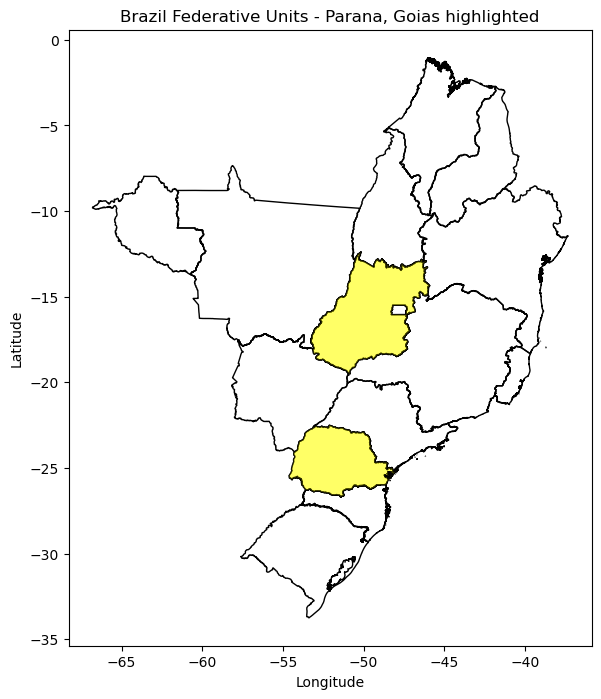

In [21]:
# 1. Visualize Brazil level 1 administrative boundaries (Federative Units) from the geojson file
gdf = gpd.read_file(DATA_GEOJSON)
selected_states_gdf = gdf[gdf['NAME_1'].isin(SELECTED_STATES)]

# Highlight selected states
ax = gdf.plot(figsize=(8, 8), edgecolor='black', facecolor='none')
selected_states_gdf.plot(ax=ax, edgecolor='black', facecolor='yellow', alpha=0.6)
ax.set_title(f'Brazil Federative Units - {", ".join(SELECTED_STATES)} highlighted')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

- The GEOJSON file contains columns with yield, production, and harvested area from 1990 to 2025 as provided by [CONAB](https://urldefense.com/v3/__https://www.gov.br/conab/pt-br/atuacao/informacoes-agropecuarias/safras/series-historicas/graos/milho/milho2aseriehist.xls/view__;!!D9dNQwwGXtA!TxHzPbDFqMEfV2wFYto34SoiIi1kP4iD1Caa8ZkyjGiXVLIa3VKOSiGuW6_crcRi4MRFiT7Y0uihSn2S24NbMHmBUuj85J8ljXDS$). 
The historical **production** (which accounts for both yield and area harvested) and **yield** are plotted for comparison with the other states.

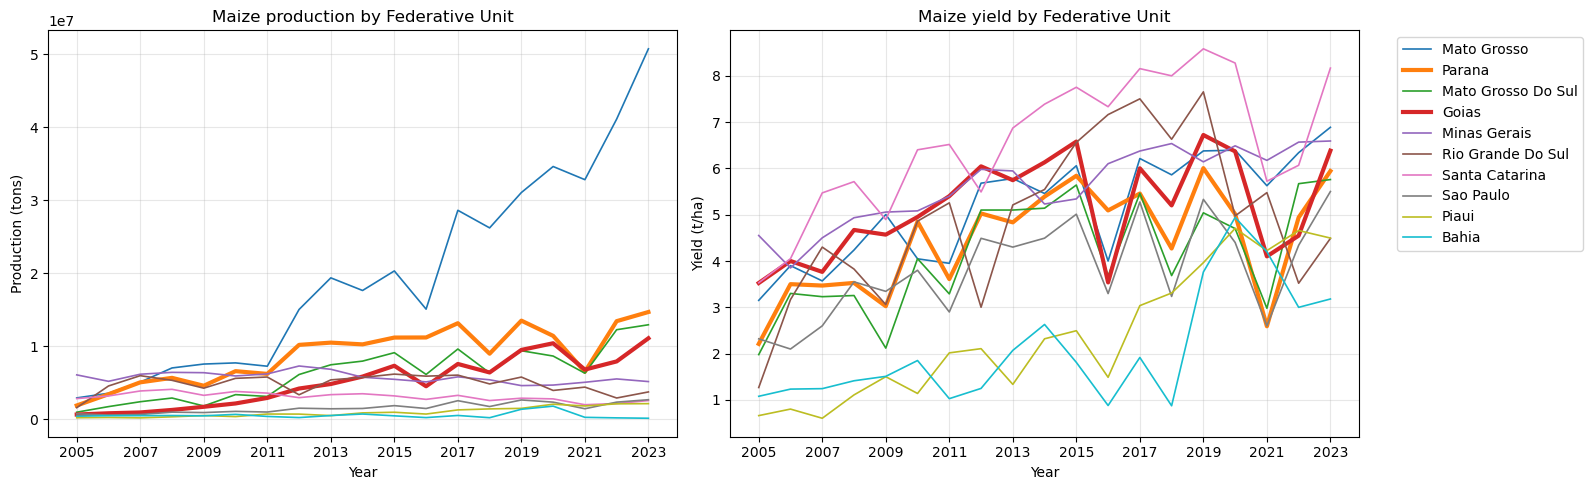

In [5]:
# 2. Visualize maize production and yield for selected states and compare with all Federative Units
prod_cols = [f"prod_{year}" for year in range(2005, 2024)]
yield_cols = [f"yield_{year}" for year in range(2005, 2024)]

# Convert from wide to long format
prod = gdf[["NAME_1"] + prod_cols].melt(id_vars="NAME_1", value_vars=prod_cols, var_name="year", value_name="prod")
yield_long = gdf[["NAME_1"] + yield_cols].melt(id_vars="NAME_1", value_vars=yield_cols, var_name="year", value_name="yield")

# Extract year 
prod["year"] = (prod["year"].str.replace("prod_", "").astype(int))
yield_long["year"] = yield_long["year"].str.replace("yield_", "").astype(int)

states_to_plot = (prod.groupby("NAME_1")["prod"].max().sort_values(ascending=False).head(10).index)

cmap = colormaps["tab10"]
state_colors = {state: cmap(i)
    for i, state in enumerate(states_to_plot)}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
for state in states_to_plot:
    prod_data = prod[prod["NAME_1"] == state]
    yield_data = yield_long[yield_long["NAME_1"] == state]

    label = state if state in SELECTED_STATES else state
    lw = 3 if state in SELECTED_STATES else 1.2

    axes[0].plot(prod_data["year"], prod_data["prod"],
        linewidth=lw, label=label, color=state_colors[state])

    axes[1].plot(yield_data["year"], yield_data["yield"],
        linewidth=lw, label=label, color=state_colors[state])

axes[0].set_title("Maize production by Federative Unit")
axes[0].set_ylabel("Production (tons)")

axes[1].set_title("Maize yield by Federative Unit")
axes[1].set_ylabel("Yield (t/ha)")

for ax in axes:
    ax.set_xlabel("Year")
    ax.set_xticks(range(2005, 2025, 2))
    ax.grid(True, alpha=0.3)

axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# 3. OpenEO processing & feature preparation
In this section, the core ARYA preprocessing chain is run on a single season to keep class runtime low while preserving the full production logic. The workflow consists of:
1. The spatial extent and temporal window are retrieved as defined by users at the beginning of this notebook.
2. Input data, including MODIS, the maize crop type maps from WorldCereal and reanalysis data from AGERA5, are accessed through the openEO platform.
3. Both the maize-masked maps and AGERA5 temperature are spatially aggregated to AU polygons and exported as CSV files for subsequent Gaussian fitting and yield forecasting.

In [17]:
RUN_OPENEO = True
if RUN_OPENEO:
    c = openeo.connect("openeo.vito.be").authenticate_oidc(provider_id="terrascope")
    temporal_extent = [DEMO_START, DEMO_END]
    state_info = {}

    for state_name in SELECTED_STATES:
        gdf_job = gdf[gdf["NAME_1"] == state_name][["num_ID", "NAME_1", "geometry"]].copy()
        minx, miny, maxx, maxy = gdf_job.total_bounds
        
        state_info[state_name] = {
            "gdf": gdf_job,
            "geoms": gdf_job.__geo_interface__,
            "spatial_extent": {
                "west": float(minx),
                "south": float(miny),
                "east": float(maxx),
                "north": float(maxy),
                "crs": 4326}, }
        
        print(state_name)
        print(state_info[state_name]["spatial_extent"])
else:
    state_info = {}
    print("RUN_OPENEO is False. Skipping OpenEO processing and using available CSV files.")

Authenticated using refresh token.
Goias
{'west': -53.25072097799992, 'south': -19.49882125899994, 'east': -45.90655517599998, 'north': -12.394891739, 'crs': 4326}


### **Step 1: MODIS DVI Calculation**

The **Moderate Resolution Imaging Spectroradiometer** ([MODIS](https://modis.gsfc.nasa.gov/about/)) is the main optical instrument operating on NASA’s Terra and Aqua satellites, providing near-daily global observations since 2000 at 250m resolution. Its global historical archive of over 20 years with daily observations makes it particularly suitable for monitoring purposes at national and subnational scales. 

In this notebook, MODIS surface reflectance is accessed through the **VITO openEO platform**, which provides Collection 6 daily surface reflectance products (M{O,Y}D09GQ), atmospherically and geometrically corrected based on the VJB method [Vermote et. al (2008)](https://doi.org/10.1109/TGRS.2008.2005977) and BRDF normalized to reduce variations caused by changing illumination and viewing geometry from the two satellites.

To characterize crop growth, the **Difference Vegetation Index (DVI)** is then computed from MODIS surface reflectance as:
$$
\mathrm{DVI} = \mathrm{NIR} - \mathrm{RED} = \mathrm{B02} - \mathrm{B01}
$$
Healthy vegetation generally strongly reflects near-infrared (NIR) light and absorbs RED light for photosynthesis; therefore, **DVI tracks canopy vigour and biomass development**.
ARYA uses DVI since it provides a stable representation of crop growth, particularly in dense canopies and during periods of rapid biomass accumulation without saturating.

In [9]:
# Load the MODIS data and calculate DVI
if RUN_OPENEO:
    for state_name, info in state_info.items():
        print(f"Processing MODIS DVI for {state_name}")
        modis = c.load_collection('MODIS', spatial_extent=info["spatial_extent"], temporal_extent=temporal_extent, bands=['B01', 'B02'])
        red = modis.band('B01')
        nir = modis.band('B02')
        dvi = nir - red
        dvi_state = dvi.aggregate_spatial(geometries=info["geoms"], reducer="mean")

        # Save in output directory
        state_dir = OUT_DIR / 'modis' / state_name.replace(" ", "_").lower()
        state_dir.mkdir(parents=True, exist_ok=True)
        job_modis = dvi_state.execute_batch(title=f"ARYA demo DVI by {state_name}", out_format='CSV', job_options={"do_extent_check": False})
        job_modis.download_results(target=state_dir)
        print(f"DVI time series and reference GeoTIFF exported to {state_dir}")
else:
    print("RUN_OPENEO is False. Skipping MODIS DVI processing and using available CSV files.")

Processing MODIS DVI for Parana
0:00:00 Job 'j-260615125803468fbd3dbfff39a288bf': send 'start'
0:01:04 Job 'j-260615125803468fbd3dbfff39a288bf': queued (progress 0%)
0:01:11 Job 'j-260615125803468fbd3dbfff39a288bf': queued (progress 0%)
0:01:22 Job 'j-260615125803468fbd3dbfff39a288bf': queued (progress 0%)
0:01:32 Job 'j-260615125803468fbd3dbfff39a288bf': queued (progress 0%)
0:01:42 Job 'j-260615125803468fbd3dbfff39a288bf': queued (progress 0%)
0:02:00 Job 'j-260615125803468fbd3dbfff39a288bf': running (progress 8.7%)
0:02:16 Job 'j-260615125803468fbd3dbfff39a288bf': running (progress 10.8%)
0:02:35 Job 'j-260615125803468fbd3dbfff39a288bf': running (progress 13.4%)
0:02:59 Job 'j-260615125803468fbd3dbfff39a288bf': running (progress 16.3%)
0:03:30 Job 'j-260615125803468fbd3dbfff39a288bf': running (progress 19.7%)
0:04:08 Job 'j-260615125803468fbd3dbfff39a288bf': running (progress 23.6%)
0:04:57 Job 'j-260615125803468fbd3dbfff39a288bf': running (progress 28.1%)
0:06:00 Job 'j-26061512580

/tmp/ipykernel_4048103/3663159350.py:15: UserDeprecationWarning: Call to deprecated method download_results. (Instead use `BatchJob.get_results` and the more flexible download functionality of `JobResults`) -- Deprecated since version 0.4.10.
  job_modis.download_results(target=state_dir)
/home/kate/.conda/envs/arya_openeo/lib/python3.12/site-packages/openeo/rest/job.py:199: UserDeprecationWarning: Call to deprecated method get_result. (Use `BatchJob.get_results` instead.) -- Deprecated since version 0.4.10.
  return self.get_result().download_files(target)
/home/kate/.conda/envs/arya_openeo/lib/python3.12/site-packages/openeo/rest/job.py:203: UserDeprecationWarning: Call to deprecated class _Result. (Use `JobResults` instead) -- Deprecated since version 0.4.10.
  return _Result(self)


DVI time series and reference GeoTIFF exported to /media/nas2/katecyran/worldcereal-yield-main/worldcereal-yield-main/Brazil/Outputs/modis/parana
Processing MODIS DVI for Goias
0:00:00 Job 'j-26061513042044dabe3564d2b7be9fe4': send 'start'
0:01:05 Job 'j-26061513042044dabe3564d2b7be9fe4': created (progress 0%)
0:01:10 Job 'j-26061513042044dabe3564d2b7be9fe4': queued (progress 0%)
0:01:17 Job 'j-26061513042044dabe3564d2b7be9fe4': queued (progress 0%)
0:01:25 Job 'j-26061513042044dabe3564d2b7be9fe4': queued (progress 0%)
0:01:38 Job 'j-26061513042044dabe3564d2b7be9fe4': running (progress 5.4%)
0:01:50 Job 'j-26061513042044dabe3564d2b7be9fe4': running (progress 7.2%)
0:02:06 Job 'j-26061513042044dabe3564d2b7be9fe4': running (progress 9.4%)
0:02:25 Job 'j-26061513042044dabe3564d2b7be9fe4': running (progress 12.0%)
0:02:49 Job 'j-26061513042044dabe3564d2b7be9fe4': running (progress 15.0%)
0:03:19 Job 'j-26061513042044dabe3564d2b7be9fe4': running (progress 18.5%)
0:03:58 Job 'j-2606151304204

### **Step 2: Crop-Type Filtering with WorldCereal crop type maps**

In the VITO openEO API, the following WorldCereal crop type maps at 10 m resolution are available for the 2021 year: 
- `ESA_WORLDCEREAL_WINTERCEREAL` provides crop classification for the winter cereals growing season, including winter wheat, barley, rye.
- `ESA_WORLDCEREAL_SPRINGCEREAL` provides crop classification for the spring cereals growing season, including spring wheat, barley and rye.
- **`ESA_WORLDCEREAL_MAIZE`** provides crop classification for the **maize growing season**, which is used in this Notebook **to isolate the maize signal**.

The 10 m maize classification is spatially averaged and reprojected to the MODIS grid and resolution, obtaining the maize fraction within each MODIS pixel (expressed as %).

Important: a threshold of `>= 50%` maize fraction is applied. Pixels containing at least 50% maize are retained in order to:
- reduce mixed-pixel contamination,
- and remain aligned with the ARYA methodology.

In [18]:
# 2. Load the WorldCereal maize classification and create a mask with > 50% maize cover
if RUN_OPENEO:
    for state_name, info in state_info.items():
        
        print(f"Processing ESA WORLDCEREAL MAIZE MASK for {state_name}")
        maize = c.load_collection('ESA_WORLDCEREAL_MAIZE', temporal_extent=['2021-01-01', '2021-12-31'], spatial_extent=info["spatial_extent"], 
                                bands=['CLASSIFICATION'])
    
        maize_pct = maize.band('CLASSIFICATION').apply(lambda x: (x == 100) * 100)
        maize_static = maize_pct.reduce_dimension(dimension='t', reducer='first')
        maize_pct_modis = maize_static.resample_cube_spatial(target=dvi, method='average')
        maize_mask_modis = maize_pct_modis >= 50
        dvi_maize = dvi.mask(~maize_mask_modis)
        
        dvi_state = dvi_maize.aggregate_spatial(geometries=info["geoms"], reducer='mean')
        
        # Save in output directory
        #maize_dir = OUT_DIR / 'maize' / state_name.replace(" ", "_").lower()
        #maize_dir.mkdir(parents=True, exist_ok=True)
        #job_mask = maize_pct_modis.execute_batch(title=f"Maize % in MODIS grid by {state_name}", out_format="GTiff", job_options={"do_extent_check": False})
        #job_mask.start_and_wait()
        #job_mask.download_results(target=maize_dir)
        
        dvi_dir = OUT_DIR / 'dvi' / state_name.replace(" ", "_").lower()
        job_dvi = dvi_state.execute_batch(title=f"DVI maize-masked by {state_name}", out_format='CSV', job_options={"do_extent_check": False})
        job_mask.start_and_wait()
        job_dvi.download_results(target=dvi_dir)
        print(f"Demo GeoTiff and CSV exported to {maize_dir} and {dvi_dir}")
    else:
        print("RUN_OPENEO is False. Skipping ESA WORLDCEREAL MAIZE MASK processing and using available CSV files.")

Processing ESA WORLDCEREAL MAIZE MASK for Goias


Preflight process graph validation raised: [ExtentTooLarge] collection_id 'ESA_WORLDCEREAL_MAIZE': Requested extent is too large to process. Estimated number of pixels: 2.13e+11, threshold: 1.00e+11.


0:00:00 Job 'j-2606151352424ea38f385787b41cfcaa': send 'start'
0:00:28 Job 'j-2606151352424ea38f385787b41cfcaa': queued (progress 0%)
0:00:40 Job 'j-2606151352424ea38f385787b41cfcaa': queued (progress 0%)
0:00:47 Job 'j-2606151352424ea38f385787b41cfcaa': queued (progress 0%)
0:00:55 Job 'j-2606151352424ea38f385787b41cfcaa': queued (progress 0%)
0:01:05 Job 'j-2606151352424ea38f385787b41cfcaa': queued (progress 0%)
0:01:24 Job 'j-2606151352424ea38f385787b41cfcaa': queued (progress 0%)
0:01:55 Job 'j-2606151352424ea38f385787b41cfcaa': queued (progress 0%)
0:02:14 Job 'j-2606151352424ea38f385787b41cfcaa': queued (progress 0%)
0:02:41 Job 'j-2606151352424ea38f385787b41cfcaa': queued (progress 0%)
0:03:11 Job 'j-2606151352424ea38f385787b41cfcaa': queued (progress 0%)
0:03:48 Job 'j-2606151352424ea38f385787b41cfcaa': queued (progress 0%)
0:04:35 Job 'j-2606151352424ea38f385787b41cfcaa': running (progress 29.6%)
0:05:33 Job 'j-2606151352424ea38f385787b41cfcaa': running (progress 34.1%)
0:06:3

/tmp/ipykernel_4048103/881304961.py:27: UserDeprecationWarning: Call to deprecated method download_results. (Instead use `BatchJob.get_results` and the more flexible download functionality of `JobResults`) -- Deprecated since version 0.4.10.
  job_dvi.download_results(target=dvi_dir)
/home/kate/.conda/envs/arya_openeo/lib/python3.12/site-packages/openeo/rest/job.py:199: UserDeprecationWarning: Call to deprecated method get_result. (Use `BatchJob.get_results` instead.) -- Deprecated since version 0.4.10.
  return self.get_result().download_files(target)
/home/kate/.conda/envs/arya_openeo/lib/python3.12/site-packages/openeo/rest/job.py:203: UserDeprecationWarning: Call to deprecated class _Result. (Use `JobResults` instead) -- Deprecated since version 0.4.10.
  return _Result(self)


Demo GeoTiff and CSV exported to /media/nas2/katecyran/worldcereal-yield-main/worldcereal-yield-main/Brazil/Outputs/maize/parana and /media/nas2/katecyran/worldcereal-yield-main/worldcereal-yield-main/Brazil/Outputs/dvi/goias
RUN_OPENEO is False. Skipping ESA WORLDCEREAL MAIZE MASK processing and using available CSV files.


### **Step 3: AgERA5 Temperature Processing**

AgERA5 provides daily meteorological data (at 0.1°x0.1° spatial resolution) for the period from 1979 to present, designed as input for agricultural modelling applications. This dataset is based on the hourly [ECMWF ERA5 data](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview) at surface level aggregated to daily time steps and interpolated at 0.1° grid.
In this DEMO, `temperature-mean` is used to compute Growing Degree Days (GDD) and normalize the crop phenological evolution.

In [11]:
# 3. Load the AgERA5 temperature data and calculate the mean temperature for the season in each state
if RUN_OPENEO:
    for state_name, info in state_info.items():
        print(f"Processing ERA5 temperature data for {state_name}")
        tmean = c.load_collection("AGERA5", spatial_extent=info["spatial_extent"], temporal_extent=temporal_extent, bands=["temperature-mean"])
        tmean_state = tmean.aggregate_spatial(geometries=info["geoms"], reducer="mean")

        # Save in output directory
        tmp_dir = OUT_DIR / 'tmean' / state_name.replace(" ", "_").lower()
        tmp_dir.mkdir(parents=True, exist_ok=True)
        job_tmp = tmean_state.execute_batch(title=f"ARYA demo AGERA5 by {state_name}", out_format="CSV",)
        job_tmp.start_and_wait()
        job_tmp.download_results(target=tmp_dir)
        print(f"AGERA5 temperature exported to {tmp_dir}")
else:
    print("RUN_OPENEO is False. Skipping AGERA5 temperature processing and using available CSV files.")

Processing ERA5 temperature data for Parana
0:00:00 Job 'j-2606151336324b07afb00059ea5da777': send 'start'
0:00:23 Job 'j-2606151336324b07afb00059ea5da777': created (progress 0%)
0:00:31 Job 'j-2606151336324b07afb00059ea5da777': queued (progress 0%)
0:00:40 Job 'j-2606151336324b07afb00059ea5da777': queued (progress 0%)
0:00:49 Job 'j-2606151336324b07afb00059ea5da777': queued (progress 0%)
0:00:59 Job 'j-2606151336324b07afb00059ea5da777': queued (progress 0%)
0:01:11 Job 'j-2606151336324b07afb00059ea5da777': queued (progress 0%)
0:01:33 Job 'j-2606151336324b07afb00059ea5da777': running (progress 10.5%)
0:01:58 Job 'j-2606151336324b07afb00059ea5da777': running (progress 14.0%)
0:02:22 Job 'j-2606151336324b07afb00059ea5da777': running (progress 16.9%)
0:02:54 Job 'j-2606151336324b07afb00059ea5da777': running (progress 20.5%)
0:03:32 Job 'j-2606151336324b07afb00059ea5da777': running (progress 24.3%)
0:04:19 Job 'j-2606151336324b07afb00059ea5da777': running (progress 28.5%)
0:05:26 Job 'j-2

/tmp/ipykernel_4048103/66606649.py:13: UserDeprecationWarning: Call to deprecated method download_results. (Instead use `BatchJob.get_results` and the more flexible download functionality of `JobResults`) -- Deprecated since version 0.4.10.
  job_tmp.download_results(target=tmp_dir)


AGERA5 temperature exported to /media/nas2/katecyran/worldcereal-yield-main/worldcereal-yield-main/Brazil/Outputs/tmean/parana
Processing ERA5 temperature data for Goias
0:00:00 Job 'j-26061513423342fe8d4dca522e40c177': send 'start'
0:00:20 Job 'j-26061513423342fe8d4dca522e40c177': created (progress 0%)
0:00:26 Job 'j-26061513423342fe8d4dca522e40c177': queued (progress 0%)
0:00:32 Job 'j-26061513423342fe8d4dca522e40c177': queued (progress 0%)
0:00:40 Job 'j-26061513423342fe8d4dca522e40c177': queued (progress 0%)
0:00:50 Job 'j-26061513423342fe8d4dca522e40c177': queued (progress 0%)
0:01:03 Job 'j-26061513423342fe8d4dca522e40c177': queued (progress 0%)
0:01:19 Job 'j-26061513423342fe8d4dca522e40c177': queued (progress 0%)
0:01:38 Job 'j-26061513423342fe8d4dca522e40c177': running (progress 11.7%)
0:02:02 Job 'j-26061513423342fe8d4dca522e40c177': running (progress 14.7%)
0:02:32 Job 'j-26061513423342fe8d4dca522e40c177': running (progress 18.2%)
0:03:10 Job 'j-26061513423342fe8d4dca522e40c

# 4. Visualizing the WorldCereal maize classification
In this section, the `ESA_WORLDCEREAL_MAIZE` resampled to MODIS is visualized as a percentage of maize fraction within each MODIS pixel. 

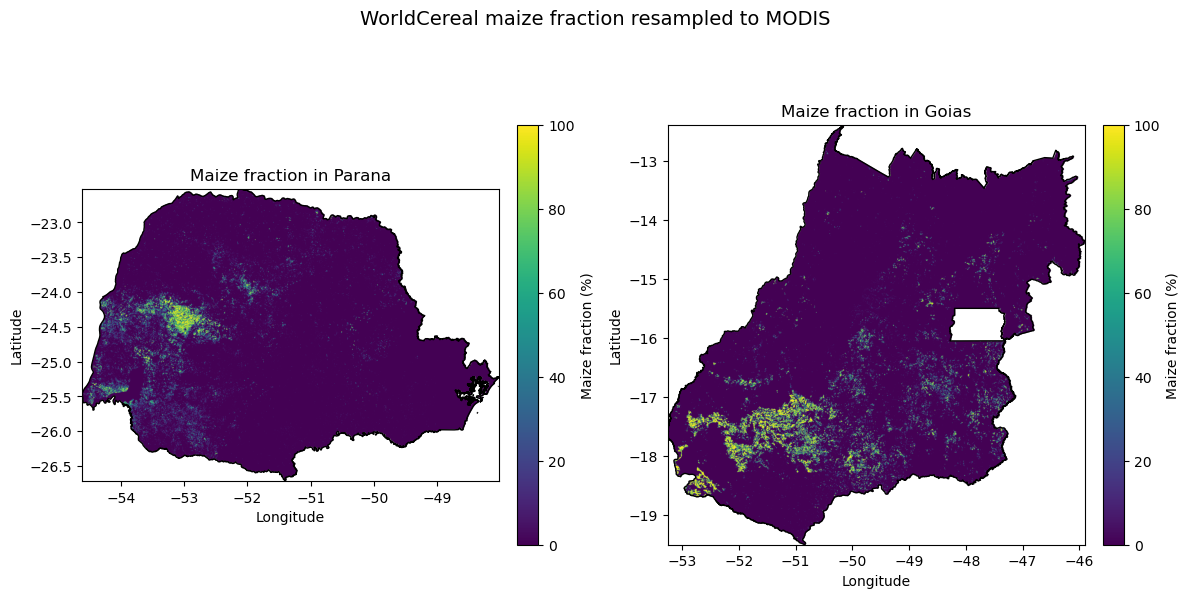

In [12]:
# Create a figure with subplots for each selected state
n_states = len(SELECTED_STATES)
fig, axes = plt.subplots(1, n_states, figsize=(6*n_states, 6))
if n_states == 1:
    axes = [axes]

for idx, state_name in enumerate(SELECTED_STATES):
    maize_tif = OUT_DIR / 'maize' / state_name.replace(" ", "_").lower() / "openEO.tif"
    selected_state_gdf = gdf[gdf["NAME_1"] == state_name][["num_ID", "NAME_1", "geometry"]].copy()

    with rasterio.open(maize_tif) as src:
        maize_crs = src.crs
        if selected_state_gdf.crs != maize_crs:
            selected_state_gdf = selected_state_gdf.to_crs(maize_crs)
        state_geom = selected_state_gdf.geometry.values
        maize_crop, maize_transform = mask(src, state_geom, crop=True, filled=False)

    maize_arr = maize_crop[0].astype(float)
    maize_arr[maize_crop[0].mask] = np.nan
    maize_extent = plotting_extent(maize_arr, maize_transform)

    ax = axes[idx]
    im = ax.imshow(maize_arr, cmap="viridis", extent=maize_extent, origin="upper", vmin=0, vmax=100)
    selected_state_gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

    ax.set_title(f"Maize fraction in {state_name}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    fig.colorbar(im, ax=ax, label="Maize fraction (%)", fraction=0.046, pad=0.04)

plt.suptitle("WorldCereal maize fraction resampled to MODIS", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 5. Fitting the Gaussian function

In this section, the extracted maize-masked DVI time series and the daily mean temperature at AU scale are combined to describe the seasonal maize development curve for Paraná. The crop evolution is modeled in **thermal time** instead of calendar time, following the principle that crop evoluation is primarily driven by accumulated temperature [McMaster & Wilhelm (1997)](https://doi.org/10.1016/S0168-1923(97)00027-0).

1. The mean daily temperature data loaded from AgERA5 are used to calculate **accumulated Growing Degree Days (GDD)**.
**Why GDD is important?**
GDD helps normalize crop evolution across years/regions with different weather trajectories. Two seasons can reach similar phenological stages at similar accumulated thermal time, even on different calendar dates. The equation used is:

$$\mathrm{GDD}_{day}=\max\!\left(T_{mean,day}-T_{base},\,0\right)$$
$$\mathrm{GDD}_{accum}(d)=\sum_{i=1}^{d}\mathrm{GDD}_{day,i}$$

with:
- `Tbase = 10 °C` for the maize crop
- `D = median(last 15 DVI days)`

2. A **Gaussian function** is then fitted to the DVI-GDD evolution. 
The fitted curve represents the expected seasonal trajectory of crop development, with low DVI values at the beginning and end of the season and a peak around maximum canopy development. The following function is used to estimate the curve development:

$$\mathrm{DVI}(d)=A\cdot\exp\left(-\frac{1}{2}\left(\frac{\mathrm{GDD}_{accum}(d)-B}{C}\right)^2\right)+D$$

Interpretation:
- **A**: amplitude above baseline (signal strength / canopy vigor). Often related to yield potential.
- **B**: thermal-time location of peak greenness (timing).
- **C**: curve width in thermal time (effective duration of active canopy).
- **D**: baseline/background component (soil/residual vegetation).

A fixed baseline value is used to represent the background DVI level. The `R2` and `RMSE` are calculated to evaluate fit quality. 

The outputs saved from this step are:

`GAUSS_PARAMS_CSV` containing the fitted Gaussian parameters and model performance metrics; and
`GAUSS_SERIES_CSV` containing the original DVI observations, accumulated GDD, and fitted DVI values.


In [22]:
# Load the DVI and temperature time series for selected states exported from openEO
all_dvi = []
all_tmp = []
feature_maps = []

for state_name in SELECTED_STATES:
    state_id = state_name.replace(" ", "_").lower()

    dvi_df = pd.read_csv(next((OUT_DIR / 'dvi' / state_id).glob("*.csv"))).rename(columns={"band_unnamed": "dvi"})
    tmp_df = pd.read_csv(next((OUT_DIR / 'tmean' / state_id).glob("*.csv")))

    dvi_df["date"] = pd.to_datetime(dvi_df["date"])
    tmp_df["date"] = pd.to_datetime(tmp_df["date"])

    dvi_df["state_name"] = state_name
    tmp_df["state_name"] = state_name

    all_dvi.append(dvi_df)
    all_tmp.append(tmp_df)

    gdf_job = gdf[gdf["NAME_1"] == state_name][
        ["num_ID", "NAME_1", "geometry"]].copy()

    feature_map_state = gdf_job.reset_index(drop=True)
    feature_map_state["feature_index"] = feature_map_state.index
    feature_map_state["state_name"] = state_name
    feature_map_state["geometry_wkt"] = feature_map_state.geometry.to_wkt()

    feature_maps.append(feature_map_state)

dvi_df = pd.concat(all_dvi, ignore_index=True)
tmp_df = pd.concat(all_tmp, ignore_index=True)
feature_map = pd.concat(feature_maps, ignore_index=True)


df = dvi_df.merge(tmp_df[["date", "feature_index", "state_name", "temperature-mean"]],
    on=["date", "feature_index", "state_name"], how="inner")

# Convert temperature units if backend returned Kelvin * 100
if df["temperature-mean"].median() > 100:
    df["temperature-mean"] = df["temperature-mean"] / 100.0 - 273.15

print(feature_map[["num_ID", "NAME_1", "feature_index"]].drop_duplicates().sort_values(["NAME_1", "num_ID"]).to_string(index=False))

# Gaussian model used to describe crop development
def gauss_model(x, a, b, c, d):
    return a * np.exp(-0.5 * ((x - b) / c) ** 2) + d

params_rows = []
series_rows = []

for (state_name, fidx), grp in df.groupby(["state_name", "feature_index"]):
    grp = grp.sort_values('date').copy()
    if len(grp) < 20:
        continue

    d_baseline = 0.11  # Fixed baseline DVI value of soil
    Tbase = 10.0  # Base temperature for maize
    grp['gdd_day'] = np.maximum(grp['temperature-mean'] - Tbase, 0.0)
    grp['gdd_accum'] = grp['gdd_day'].cumsum()

    x = grp['gdd_accum'].to_numpy(float)
    y = grp['dvi'].to_numpy(float)
    if np.nanstd(y) < 1e-8:
        continue
    
    # Initial parameter estimates for curve fitting
    a0 = float(max(np.nanmax(y) - d_baseline, 0.01))
    b0 = float(x[np.nanargmax(y)])
    c0 = float(max((np.nanmax(x) - np.nanmin(x)) / 4.0, 1.0))
    print("State:", state_name)
    print("a0, b0, c0, d:", a0, b0, c0, d_baseline)

    try:
        popt, _ = curve_fit(
            lambda xx, a, b, c: gauss_model(xx, a, b, c, d_baseline),
            x, y, p0=[a0, b0, c0],
            bounds=([0.0, np.nanmin(x)-1000.0, 1e-3], [1.0, np.nanmax(x)+1000.0, 10000.0]),
            maxfev=20000
        )
    except Exception as e:
        print(f"curve_fit failed for feature {fidx}: {e}")
        continue

    # Extract fitted Gaussian parameters
    a_fit, b_fit, c_fit = [float(v) for v in popt]
    y_hat = gauss_model(x, a_fit, b_fit, c_fit, d_baseline)

    # Calculate goodness-of-fit metrics
    resid = y - y_hat
    rmse = float(np.sqrt(np.nanmean(resid ** 2)))
    ss_res = float(np.nansum(resid ** 2))
    ss_tot = float(np.nansum((y - np.nanmean(y)) ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan

    match = feature_map.loc[(feature_map["state_name"] == state_name) & (feature_map["feature_index"] == int(fidx))]
    print("n matches for feature", fidx, "=", len(match))

    info = match.iloc[0]

    # Store fitted parameters and time series with predictions
    params_rows.append({
        'feature_index': int(fidx),
        'num_ID': info['num_ID'],
        'state_name': info['NAME_1'],
        'geometry_wkt': info['geometry_wkt'],
        'A': a_fit, 'B': b_fit, 'C': c_fit, 'D': d_baseline,
        'R2': r2, 'RMSE': rmse, 'n_obs': len(grp)})

    grp['dvi_pred'] = y_hat
    grp['num_ID'] = info['num_ID']
    grp['state_name'] = info['NAME_1']
    grp['geometry_wkt'] = info['geometry_wkt']
    grp['A'] = a_fit
    grp['B'] = b_fit
    grp['C'] = c_fit
    grp['D'] = d_baseline

    series_rows.append(grp[['date','feature_index','num_ID','state_name','geometry_wkt','dvi','temperature-mean','gdd_day','gdd_accum','dvi_pred','A','B','C','D']])

# Create output tables 
params_df = pd.DataFrame(params_rows)
if not params_df.empty:
    params_df = params_df.sort_values(["state_name", "feature_index"])
else:
    print("No fitted parameters produced.")

series_df = pd.concat(series_rows, axis=0).sort_values(["state_name", "feature_index", "date"]) if series_rows else pd.DataFrame()

# Save Gaussian parameters and fitted series
params_df.to_csv(GAUSS_PARAMS_CSV, index=False)
series_df.to_csv(GAUSS_SERIES_CSV, index=False)

print('Saved:', GAUSS_PARAMS_CSV)
print('Saved:', GAUSS_SERIES_CSV)
params_df.head()

 num_ID NAME_1  feature_index
      4  Goias              0
      9 Parana              0
State: Goias
a0, b0, c0, d: 0.4853689726278171 1591.4701080515892 669.0304278494264 0.11
n matches for feature 0 = 1
State: Parana
a0, b0, c0, d: 0.4051035230902764 1177.1711111111142 551.6980400451228 0.11
n matches for feature 0 = 1
Saved: /media/nas2/katecyran/worldcereal-yield-main/worldcereal-yield-main/Brazil/Outputs/gaussian_fit_params.csv
Saved: /media/nas2/katecyran/worldcereal-yield-main/worldcereal-yield-main/Brazil/Outputs/gaussian_fit_timeseries.csv


,feature_index,num_ID,state_name,geometry_wkt,A,B,C,D,R2,RMSE,n_obs
0,0,4,Goias,"MULTIPOLYGON (((-46.113724 -12.917444, -46.111...",0.477091,1540.131641,403.598760,0.11,0.917549,0.046278,182
1,0,9,Parana,"MULTIPOLYGON (((-48.590252 -25.976858, -48.590...",0.423939,1149.227332,372.613469,0.11,0.921268,0.040302,182


## 6. Visualizing the Gaussian fitting

This section provides the performance visuals for the **observed vs fitted DVI over calendar time and GDD** to show the phenology fit view, with the corresponding `R2` and  `RMSE` metrics for the Paranà state.

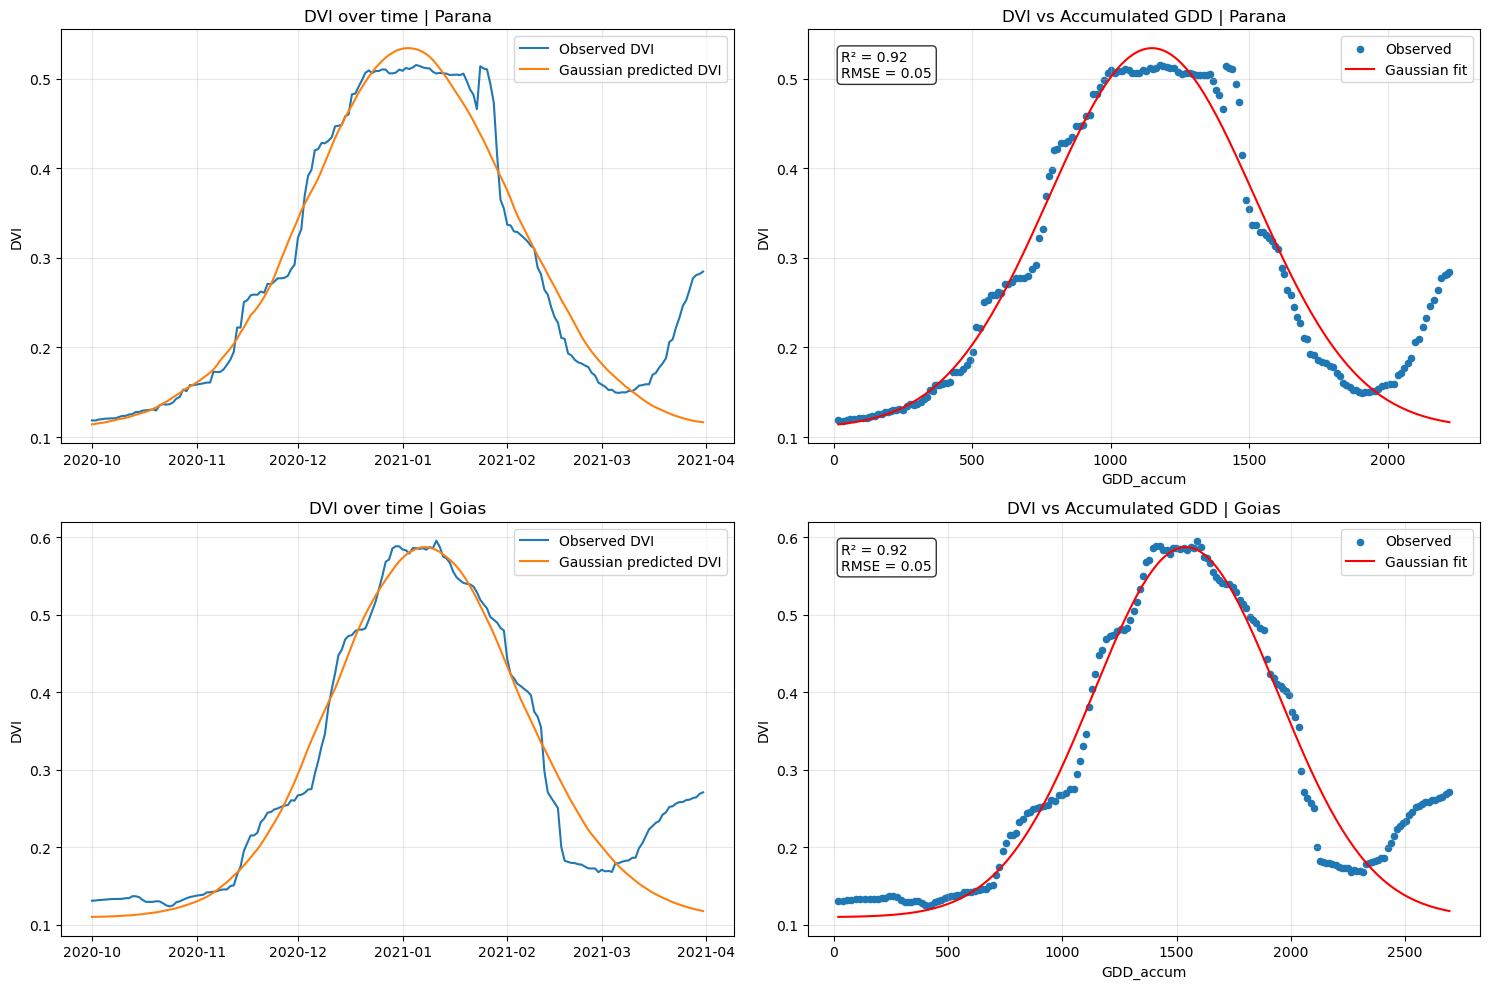

In [28]:
# Create plots for each selected state
n_states = len(SELECTED_STATES)
fig, axes = plt.subplots(n_states, 2, figsize=(15, 5*n_states))
if n_states == 1:
    axes = axes.reshape(1, -1)

for state_idx, state_name in enumerate(SELECTED_STATES):
    # Get data for this state
    state_params = params_df[params_df['state_name'] == state_name]
    if state_params.empty:
        print(f'No results for {state_name}')
        continue
        
    fidx = int(state_params.sort_values('R2', ascending=False).iloc[0]['feature_index'])
    one = series_df[(series_df["state_name"] == state_name) & (series_df['feature_index'] == fidx)].copy()
    
    fit_stats = params_df[params_df["feature_index"] == fidx].iloc[0]
    r2 = fit_stats["R2"]
    rmse = fit_stats["RMSE"]
    
    # Left plot: DVI over time
    axes[state_idx, 0].plot(one['date'], one['dvi'], label='Observed DVI')
    axes[state_idx, 0].plot(one['date'], one['dvi_pred'], label='Gaussian predicted DVI')
    axes[state_idx, 0].set_title(f"DVI over time | {state_name}")
    axes[state_idx, 0].set_ylabel('DVI')
    axes[state_idx, 0].legend()
    axes[state_idx, 0].grid(True, alpha=0.3)
    
    # Right plot: DVI vs GDD
    axes[state_idx, 1].scatter(one['gdd_accum'], one['dvi'], s=20, label='Observed')
    axes[state_idx, 1].plot(one['gdd_accum'], one['dvi_pred'], color='red', label='Gaussian fit')
    axes[state_idx, 1].text(0.05, 0.95, f"R² = {r2:.2f}\nRMSE = {rmse:.2f}", 
                            transform=axes[state_idx, 1].transAxes, verticalalignment='top', 
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    axes[state_idx, 1].set_title(f'DVI vs Accumulated GDD | {state_name}')
    axes[state_idx, 1].set_xlabel('GDD_accum')
    axes[state_idx, 1].set_ylabel('DVI')
    axes[state_idx, 1].legend()
    axes[state_idx, 1].grid(True, alpha=0.3)
    
plt.tight_layout()
plt.show()


## 7. Apply the ARYA yield forecasting model

This section merges Gaussian components with external yield coefficients from `data/coefficients_PW.csv` to produce daily yield estimates.

Model used:
$$\mathrm{yield}=a\cdot A+b\cdot C+c$$

Where:
- `A`, `C`: Gaussian components from fitted DVI-GDD model. A is the curve amplitude and C is the curve width.
- `a`, `b`: empirical ARYA coefficients by `STATE` and `DOY`.
- `c`: correction factor.

The CSV file contains the coefficients for calibrating the ARYA yield model with **c1_peak** and **c2_width** of a Gaussian curve.

In [29]:
# Print the first rows of the CSV coefficient file 
coeff_df = pd.read_csv(COEFF_CSV)
print('Rows:', len(coeff_df))
print('Columns:', list(coeff_df.columns))
print(coeff_df.head())

Rows: 33759
Columns: ['Unnamed: 0', 'YEAR', 'DOY', 'FED_STATES', 'Gauss_A', 'Gauss_B', 'Gauss_C', 'Gauss_D', 'C1_peak', 'C2_width', 'c_correct']
   Unnamed: 0  YEAR  DOY  FED_STATES  Gauss_A    Gauss_B    Gauss_C  Gauss_D  \
0           0  2003   63           8  0.28841  173.05995  270.83487  0.12321   
1           1  2005   63           8  0.31448  111.05378  229.15727  0.12313   
2           2  2007   63           8  0.25339  103.16012  270.33709  0.12327   
3           3  2008   63           8  0.31843  101.07747  311.87186  0.12329   
4           4  2010   63           8  0.24257  100.64013  199.34617  0.12389   

    C1_peak  C2_width  c_correct  
0  0.524092  0.000406      1.593  
1  8.200248 -0.007910      1.593  
2  0.844054 -0.000018      1.593  
3 -0.442863  0.001554      1.593  
4  0.844054 -0.000018      1.593  


In [30]:
# Load ARYA coefficient file and remove index-like helper columns from CSV exports
coef_df = pd.read_csv(COEFF_CSV).copy()
coef_df = coef_df.loc[:, ~coef_df.columns.str.contains('^Unnamed')]

# Rename coefficient columns to simpler names used in the calculation
coef_df = coef_df.rename(columns={
    'FED_STATES': 'num_ID',
    'DOY': 'doy',
    'C1_peak': 'a',
    'C2_width': 'b',
    'c_correct': 'c',
})

# Coeff file may contain multiple years; use mean coefficient per (state, doy).
coef_use = coef_df.groupby(['num_ID', 'doy'], as_index=False)[['a', 'b', 'c']].mean()

# Prepare Gaussian time series 
ys = series_df.copy()
season_start = ys["date"].min()
ys["doy"] = (ys["date"] - season_start).dt.days + 1
ys['doy'] = ys["doy"].astype(int)

# Normalize ID dtype for robust joins
ys['num_ID'] = pd.to_numeric(ys['num_ID'], errors='coerce').astype('Int64')
coef_use['num_ID'] = pd.to_numeric(coef_use['num_ID'], errors='coerce').astype('Int64')

# Merge the Gaussian series with the ARYA coefficients and apply ARYA yield equation
yield_df = ys.merge(coef_use, on=['num_ID', 'doy'], how='inner')
yield_df['yield_model'] = yield_df['a'] * yield_df['A'] + yield_df['b'] * yield_df['C'] + yield_df['c']

matched = yield_df['yield_model'].notna().sum()
total = len(yield_df)
print(f'Matched coefficient rows: {matched}/{total}')

keep_cols = [
    'date', 'doy', 'feature_index', 'num_ID', 'state_name',
    'A', 'B', 'C', 'D', 'a', 'b', 'c', 'yield_model']

keep_cols = [c for c in keep_cols if c in yield_df.columns]
yield_out = yield_df[keep_cols].copy().sort_values(['num_ID', 'date'])

# Daily value by state
final_forecast = (yield_out.sort_values("doy").groupby(["num_ID", "state_name"]).tail(1))
yield_out.to_csv(YIELD_SERIES_CSV, index=False)

print('Saved:', YIELD_SERIES_CSV)
display(yield_out.head())
display(final_forecast[["num_ID", "state_name", "doy", "yield_model"]])

Matched coefficient rows: 203/203
Saved: /media/nas2/katecyran/worldcereal-yield-main/worldcereal-yield-main/Brazil/Outputs/yield_timeseries.csv


,date,doy,feature_index,num_ID,state_name,A,B,C,D,a,b,c,yield_model
0,2020-12-27 00:00:00+00:00,88,0,4,Goias,0.477091,1540.131641,403.59876,0.11,-0.342366,0.002650,1.593,2.499178
1,2020-12-28 00:00:00+00:00,89,0,4,Goias,0.477091,1540.131641,403.59876,0.11,-0.059073,0.002127,1.593,2.423107
2,2020-12-29 00:00:00+00:00,90,0,4,Goias,0.477091,1540.131641,403.59876,0.11,-0.313815,0.002601,1.593,2.492920
3,2020-12-30 00:00:00+00:00,91,0,4,Goias,0.477091,1540.131641,403.59876,0.11,-0.066202,0.002172,1.593,2.438016
4,2020-12-31 00:00:00+00:00,92,0,4,Goias,0.477091,1540.131641,403.59876,0.11,0.071211,0.002100,1.593,2.474555


,num_ID,state_name,doy,yield_model
94,4,Goias,182,2.298971
202,9,Parana,182,2.584686


## 8. Visualizing outputs

In this section, the forecasted yield is plotted as a function of DOY and compared against the observed yield (from the official statistics) to evaluate how the forecast evolves throughout the season. The absolute forecasting error is also displayed to visualize its deviation from the observed yield.

The figure provides insight into:

- The temporal evolution of the forecast during the season.
- The timing at which the forecast begins to stabilize.
- Whether the model systematically overestimates or underestimates the final yield.
- How forecast accuracy changes as more observations become available throughout the season.


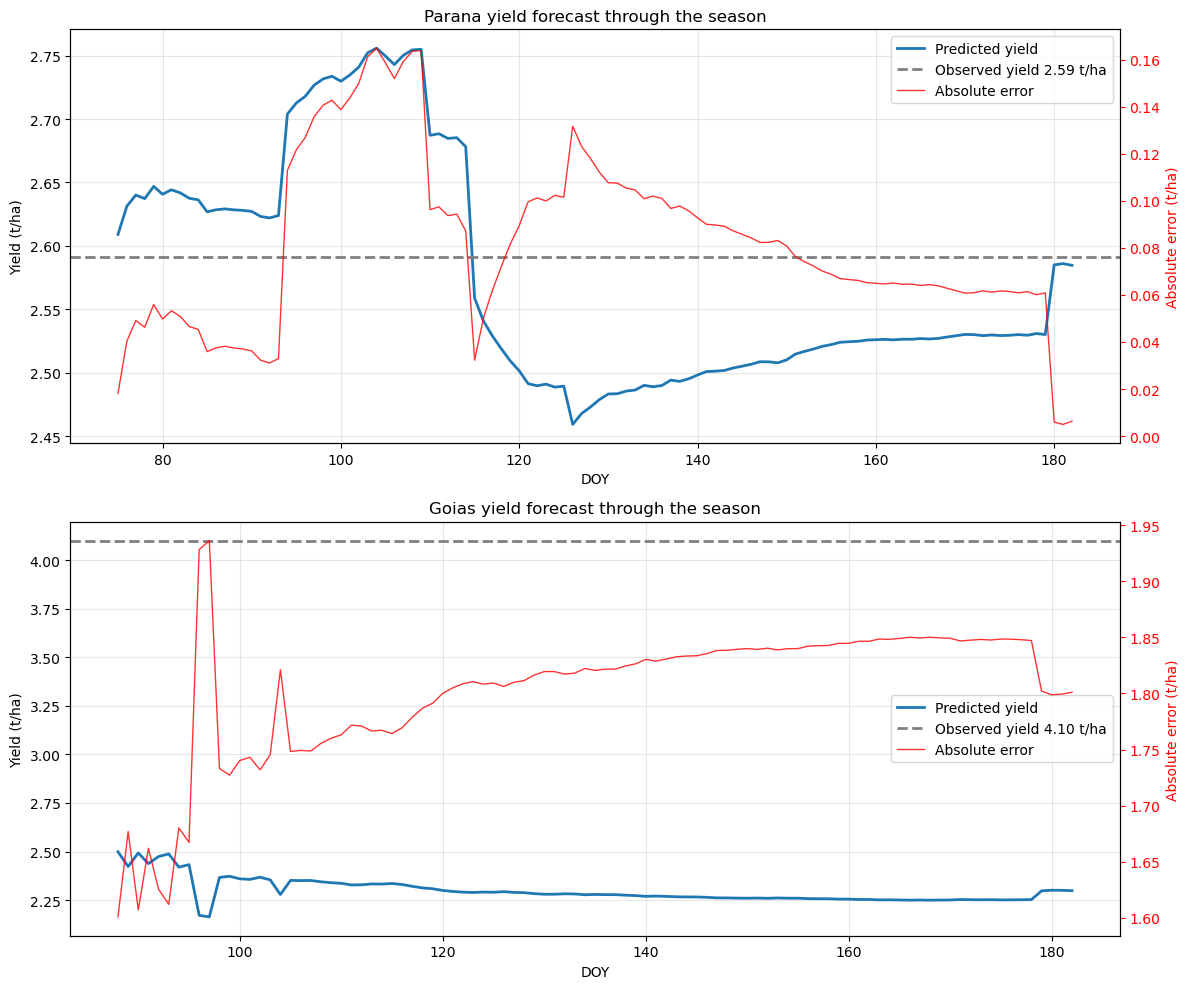


=== YIELD FORECASTS BY STATE ===
 num_ID  State  Day_of_Year  Forecasted_Yield_t_ha
      4  Goias          182               2.298971
      9 Parana          182               2.584686


In [35]:
# Create plots for each selected state
n_states = len(SELECTED_STATES)
fig, axes = plt.subplots(n_states, 1, figsize=(12, 5*n_states))
if n_states == 1:
    axes = [axes]

for state_idx, state_name in enumerate(SELECTED_STATES):
    # Filter yield data for this state
    state_yield = yield_out[yield_out['state_name'] == state_name].copy()
    
    # Get observed yield from the geoJSON
    state_obs = gdf[gdf['NAME_1'] == state_name]
    
    # Try to get 2021 yield (or latest available year)
    obs_yield = state_obs['yield_2021'].values[0] if 'yield_2021' in state_obs.columns else np.nan
    
    # Absolute error
    state_yield['abs_error'] = np.abs(state_yield['yield_model'] - obs_yield)
    
    ax1 = axes[state_idx]
    
    # Predicted yield
    ax1.plot(state_yield["doy"], state_yield["yield_model"],
        color="tab:blue", linewidth=2, label="Predicted yield")
    
    # Observed yield
    if not np.isnan(obs_yield):
        ax1.axhline(obs_yield, color="gray",
            linestyle="--", linewidth=2, label=f"Observed yield {obs_yield:.2f} t/ha")
    
    ax1.set_xlabel("DOY")
    ax1.set_ylabel("Yield (t/ha)")
    ax1.set_title(f"{state_name} yield forecast through the season")
    ax1.grid(True, alpha=0.3)
    
    # Secondary axis for error
    ax2 = ax1.twinx()
    ax2.plot(state_yield["doy"], state_yield["abs_error"],
        color="red", linewidth=1, alpha=0.8, label="Absolute error")
    
    ax2.set_ylabel("Absolute error (t/ha)", color="red")
    ax2.tick_params(axis="y", colors="red")
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.show()

# Summary table of final yields for all states
print("\n=== YIELD FORECASTS BY STATE ===")
final_forecasts = yield_out.sort_values("doy").groupby(["num_ID", "state_name"]).tail(1)
summary = final_forecasts[["num_ID", "state_name", "doy", "yield_model"]].copy()
summary.columns = ["num_ID", "State", "Day_of_Year", "Forecasted_Yield_t_ha"]
print(summary.to_string(index=False))
